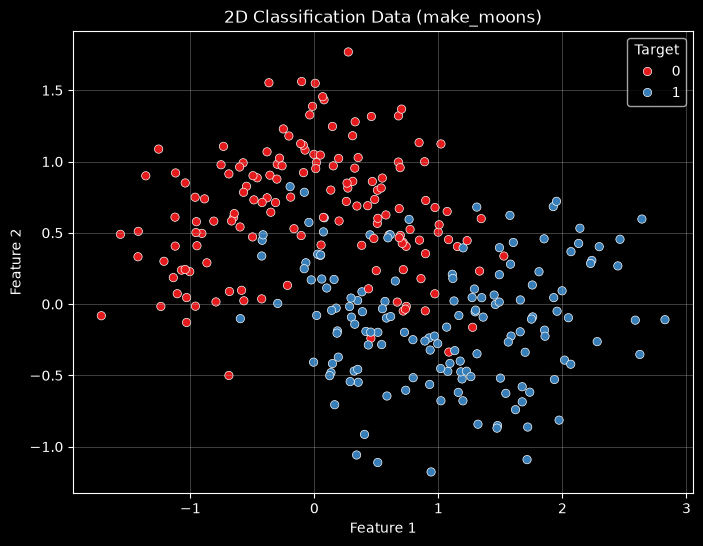

In [11]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create synthetic 2D data
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

# Create a DataFrame for plotting
df = pd.DataFrame(X, columns=["Feature 1", "Feature 2"])
df['Target'] = y

# Visualize the 2D data
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue="Target", palette="Set1")
plt.title("2D Classification Data (make_moons)")
plt.grid(True)
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)


In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Train a k-NN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict and evaluate
y_pred = knn.predict(X_test)
print(f"Test Accuracy (k=5): {accuracy_score(y_test, y_pred):.2f}")

Test Accuracy (k=5): 0.87


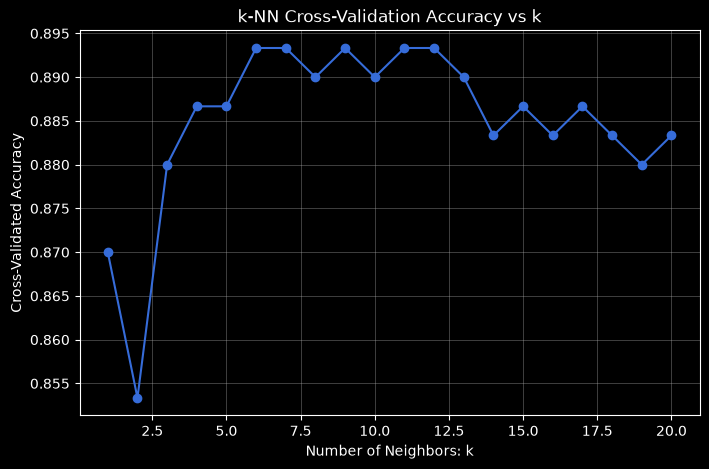

Best k from cross-validation: 6


In [5]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Range of k values to try
k_range = range(1, 21)
cv_scores = []

# Evaluate each k using 5-fold cross-validation
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot accuracy vs. k
plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores, marker='o')
plt.title("k-NN Cross-Validation Accuracy vs k")
plt.xlabel("Number of Neighbors: k")
plt.ylabel("Cross-Validated Accuracy")
plt.grid(True)
plt.show()

# Best k
best_k = k_range[np.argmax(cv_scores)]
print(f"Best k from cross-validation: {best_k}")

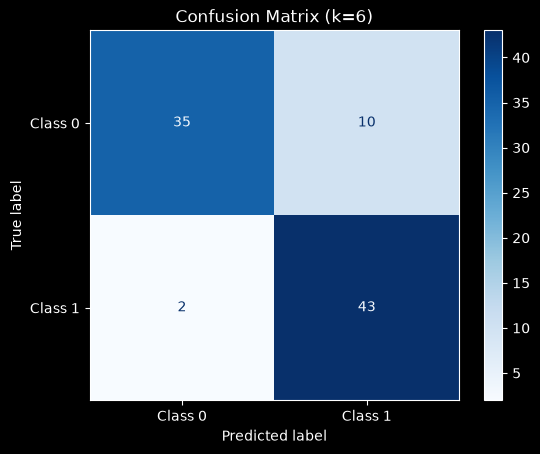

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.95      0.78      0.85        45
     Class 1       0.81      0.96      0.88        45

    accuracy                           0.87        90
   macro avg       0.88      0.87      0.87        90
weighted avg       0.88      0.87      0.87        90



In [6]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (k={best_k})")
plt.grid(False)
plt.show()

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Class 0", "Class 1"]))

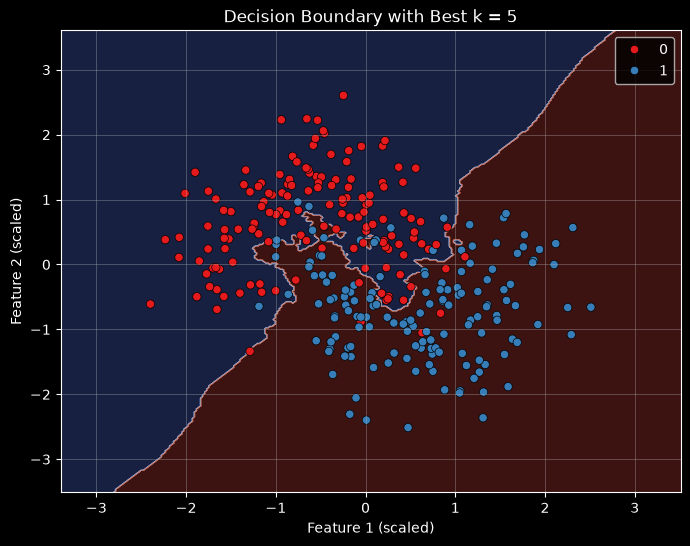

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier

# Assume X_scaled and y are already defined (scaled features + labels)

# Step 1: Train KNN with your chosen best k
best_k = 5   # for example, you can set this after tuning
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_scaled, y)

# Step 2: Create mesh grid
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Step 3: Predict on mesh grid
Z = best_knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Step 4: Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y, palette="Set1", edgecolor='k')
plt.title(f"Decision Boundary with Best k = {best_k}")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.grid(True)
plt.show()


In [13]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
iris=load_iris()
X=iris.data
print(X[:5])
X.shape


[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


(150, 4)

In [14]:
scaler = StandardScaler()
X_scaled=scaler.fit_transform(X)


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []

K_values = range(2, 11)

for k in K_values:

    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

    print(f"K = {k} | Inertia = {kmeans.inertia_:.2f} | Silhouette = {score:.3f}")

K = 2 | Inertia = 222.36 | Silhouette = 0.582
K = 3 | Inertia = 139.82 | Silhouette = 0.460
K = 4 | Inertia = 114.09 | Silhouette = 0.387
K = 5 | Inertia = 90.93 | Silhouette = 0.346
K = 6 | Inertia = 81.54 | Silhouette = 0.317
K = 7 | Inertia = 72.63 | Silhouette = 0.320
K = 8 | Inertia = 62.54 | Silhouette = 0.339
K = 9 | Inertia = 55.12 | Silhouette = 0.342
K = 10 | Inertia = 47.39 | Silhouette = 0.352


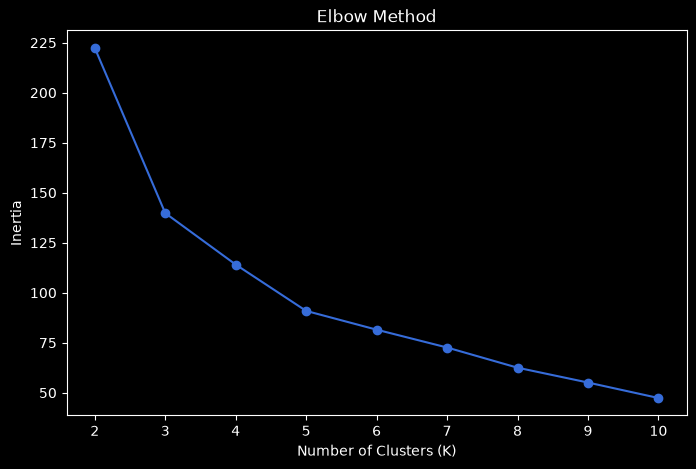

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(K_values, inertias, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(K_values)

plt.show()

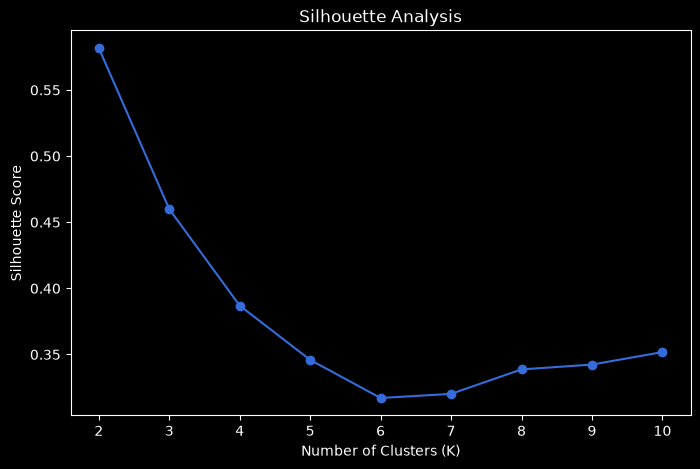

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(K_values, silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.xticks(K_values)

plt.show()